In [90]:
import pandas as pd 
from utils import (
    load_survey_responses,
    process_survey_responses,
    process_final_responses,
    aggregate_user_responses
)
import config


In [91]:
print("Loading survey responses...")
survey_df = load_survey_responses("../survey_results/survey_response/", config.SURVEY_RESPONSES_PATTERN)

Loading survey responses...


In [92]:
survey_df.columns

Index(['user_id', 'age', 'gender', 'marital_status', 'has_children',
       'nationality', 'city', 'disability', 'pets', 'profession', 'hobbies',
       'interests', 'travel_experience', 'preferred_travel_style', 'poi_id',
       'poi_title', 'is_manual_first', 'manual_significance', 'manual_trust',
       'manual_clarity', 'ai_significance', 'ai_trust', 'ai_clarity',
       'engaging_preference', 'relevant_preference', 'eager_preference',
       'title_preference', 'description_preference', 'already_visited',
       'timestamp'],
      dtype='object')

In [68]:
survey_df

,user_id,age,gender,marital_status,has_children,nationality,city,disability,pets,profession,...,ai_significance,ai_trust,ai_clarity,engaging_preference,relevant_preference,eager_preference,title_preference,description_preference,already_visited,timestamp
0,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Agree,Very,Clear,Version B,Version B,Version B,Version B,Version B,I have never heard of it before.,2024-12-16T12:55:40.540271
1,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Agree,Very,Clear,Version B,Version B,Version B,Version B,Version B,I have never heard of it before.,2024-12-16T12:57:24.904851
2,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Neutral,Moderately,Neutral,Version A,Version A,Version A,Version A,Version A,I have never heard of it before.,2024-12-16T12:58:44.648347
3,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Agree,Moderately,Clear,Version A,Version A,Version B,Version A,Version A,I have never heard of it before.,2024-12-16T13:01:23.608229
4,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Neutral,Moderately,Neutral,Version A,Version A,Version A,Both equally,Both equally,I have never heard of it before.,2024-12-16T13:03:18.750496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Disagree,Slightly,Neutral,Version A,Version A,Both equally,Version B,Version A,I have visited it in person.,2025-02-05T14:58:36.555090
506,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Neutral,Not at all,Unclear,Version B,Version A,Both equally,Both equally,Version A,I have visited it in person.,2025-02-05T15:01:05.184466
507,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Agree,Moderately,Unclear,Version A,Version B,Both equally,Version A,Both equally,I have visited it in person.,2025-02-05T15:02:10.128365
508,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Neutral,Moderately,Neutral,Version B,Both equally,Both equally,Version A,Both equally,I have never heard of it before.,2025-02-05T15:03:43.711735


In [93]:

survey_df ['timestamp']= pd.to_datetime(survey_df['timestamp'])
# filter_date = pd.to_datetime('2025-01-28')
# survey_df = survey_df[survey_df['timestamp'] >= filter_date]
survey_df

,user_id,age,gender,marital_status,has_children,nationality,city,disability,pets,profession,...,ai_significance,ai_trust,ai_clarity,engaging_preference,relevant_preference,eager_preference,title_preference,description_preference,already_visited,timestamp
0,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Agree,Very,Clear,Version B,Version B,Version B,Version B,Version B,I have never heard of it before.,2024-12-16 12:55:40.540271
1,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Agree,Very,Clear,Version B,Version B,Version B,Version B,Version B,I have never heard of it before.,2024-12-16 12:57:24.904851
2,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Neutral,Moderately,Neutral,Version A,Version A,Version A,Version A,Version A,I have never heard of it before.,2024-12-16 12:58:44.648347
3,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Agree,Moderately,Clear,Version A,Version A,Version B,Version A,Version A,I have never heard of it before.,2024-12-16 13:01:23.608229
4,e6dd2d90-fc52-4004-b29e-b36e267e541c,31,Female,Married,Yes,Indian,Stuttgart,No,No,NaN,...,Neutral,Moderately,Neutral,Version A,Version A,Version A,Both equally,Both equally,I have never heard of it before.,2024-12-16 13:03:18.750496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Disagree,Slightly,Neutral,Version A,Version A,Both equally,Version B,Version A,I have visited it in person.,2025-02-05 14:58:36.555090
506,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Neutral,Not at all,Unclear,Version B,Version A,Both equally,Both equally,Version A,I have visited it in person.,2025-02-05 15:01:05.184466
507,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Agree,Moderately,Unclear,Version A,Version B,Both equally,Version A,Both equally,I have visited it in person.,2025-02-05 15:02:10.128365
508,7d6d9947-09cb-45d8-a134-415cfc87c299,23,Male,Single,No,German,Bietigheim,No,No,Student,...,Neutral,Moderately,Neutral,Version B,Both equally,Both equally,Version A,Both equally,I have never heard of it before.,2025-02-05 15:03:43.711735


In [94]:
# take dataframe with unique user_id from survey_df
survey_df_unique = survey_df.drop_duplicates(subset=['user_id'], keep='last')

In [95]:
# frequency distribution of different gender
survey_df_unique['gender'].value_counts(),

(gender
 Male      34
 Female    17
 Name: count, dtype: int64,)

In [96]:
survey_df_unique['marital_status'].value_counts()  

marital_status
Married              25
Single               22
In a Relationship     3
Divorced              1
Name: count, dtype: int64

In [97]:
survey_df_unique['profession'].value_counts()

profession
Student                      22
Engineer                     16
Academic/Professor            3
Government/Public Service     1
Self-employed                 1
Doctor/Healthcare             1
Name: count, dtype: int64

In [98]:
survey_df_unique['nationality'].value_counts()

nationality
Indian     28
German     21
Chinese     1
Iranian     1
Name: count, dtype: int64

In [75]:
!uv add matplotlib

Resolved 58 packages in 0.87ms
Audited 57 packages in 2ms


In [76]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIX Two Text", "Times New Roman", "Georgia", "DejaVu Serif"],
    "figure.titlesize": 18,
    "axes.labelsize": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#1a1a1a",
    "axes.linewidth": 1.1,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

ACADEMIC_THEME = {
    "background": "#f9f9fb",
    "panel": "#ffffff",
    "manual": "#3d5a80",
    "ai": "#bc4123",
    "accent": "#5f0f40",
    "grid": "#d7d7e0",
    "text": "#1f1f1f"
}

FIGURE_DIR = Path("../assets/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def plot_graph(df, cat_type, column_name1, column_name2, title, slug=None):
    df[column_name1] = df[column_name1].astype(cat_type)
    df[column_name2] = df[column_name2].astype(cat_type)

    manual_counts = (
        df[column_name1]
        .value_counts()
        .reindex(cat_type.categories)
        .fillna(0)
    )
    ai_counts = (
        df[column_name2]
        .value_counts()
        .reindex(cat_type.categories)
        .fillna(0)
    )
    manual_values = manual_counts.to_numpy(dtype=float)
    ai_values = ai_counts.to_numpy(dtype=float)
    manual_errors = np.sqrt(manual_values)
    ai_errors = np.sqrt(ai_values)

    x = np.arange(len(cat_type.categories))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
    fig.patch.set_facecolor(ACADEMIC_THEME["background"])
    ax.set_facecolor(ACADEMIC_THEME["panel"])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color(ACADEMIC_THEME["grid"])
    ax.spines["left"].set_color(ACADEMIC_THEME["grid"])
    ax.tick_params(colors=ACADEMIC_THEME["text"], labelcolor=ACADEMIC_THEME["text"])

    manual_label = "Manual"
    ai_label = "AI"

    manual_bars = ax.bar(
        x - width / 2,
        manual_values,
        width=width,
        label=manual_label,
        color=ACADEMIC_THEME["manual"],
        yerr=manual_errors,
        capsize=6,
        ecolor=ACADEMIC_THEME["accent"],
        error_kw={"elinewidth": 1.1}
    )
    ai_bars = ax.bar(
        x + width / 2,
        ai_values,
        width=width,
        label=ai_label,
        color=ACADEMIC_THEME["ai"],
        yerr=ai_errors,
        capsize=6,
        ecolor=ACADEMIC_THEME["accent"],
        error_kw={"elinewidth": 1.1}
    )

    ax.set_xlabel("Rating Scale", color=ACADEMIC_THEME["text"], labelpad=10)
    ax.set_ylabel("Number of Responses", color=ACADEMIC_THEME["text"], labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(cat_type.categories, rotation=0, color=ACADEMIC_THEME["text"])
    ax.set_title(title, color=ACADEMIC_THEME["text"], loc="center", pad=16)
    ax.grid(axis="y", color=ACADEMIC_THEME["grid"], linestyle="--", linewidth=0.9, alpha=0.8)
    legend = ax.legend(frameon=False, fontsize=12)
    for text in legend.get_texts():
        text.set_color(ACADEMIC_THEME["text"])

    for bars in (manual_bars, ai_bars):
        ax.bar_label(
            bars,
            padding=4,
            color=ACADEMIC_THEME["text"],
            fontsize=11,
            fmt="%d"
        )

    plt.tight_layout()

    if slug:
        safe_slug = slug.lower().replace(" ", "_")
        output_path = FIGURE_DIR / f"{safe_slug}_comparison.png"
        fig.savefig(output_path, dpi=400, bbox_inches="tight")
        print(f"Saved figure to {output_path.resolve()}")

    plt.show()

Saved figure to C:\Users\bksai\Documents\projects\github\PoI_survey\assets\figures\significance_comparison.png


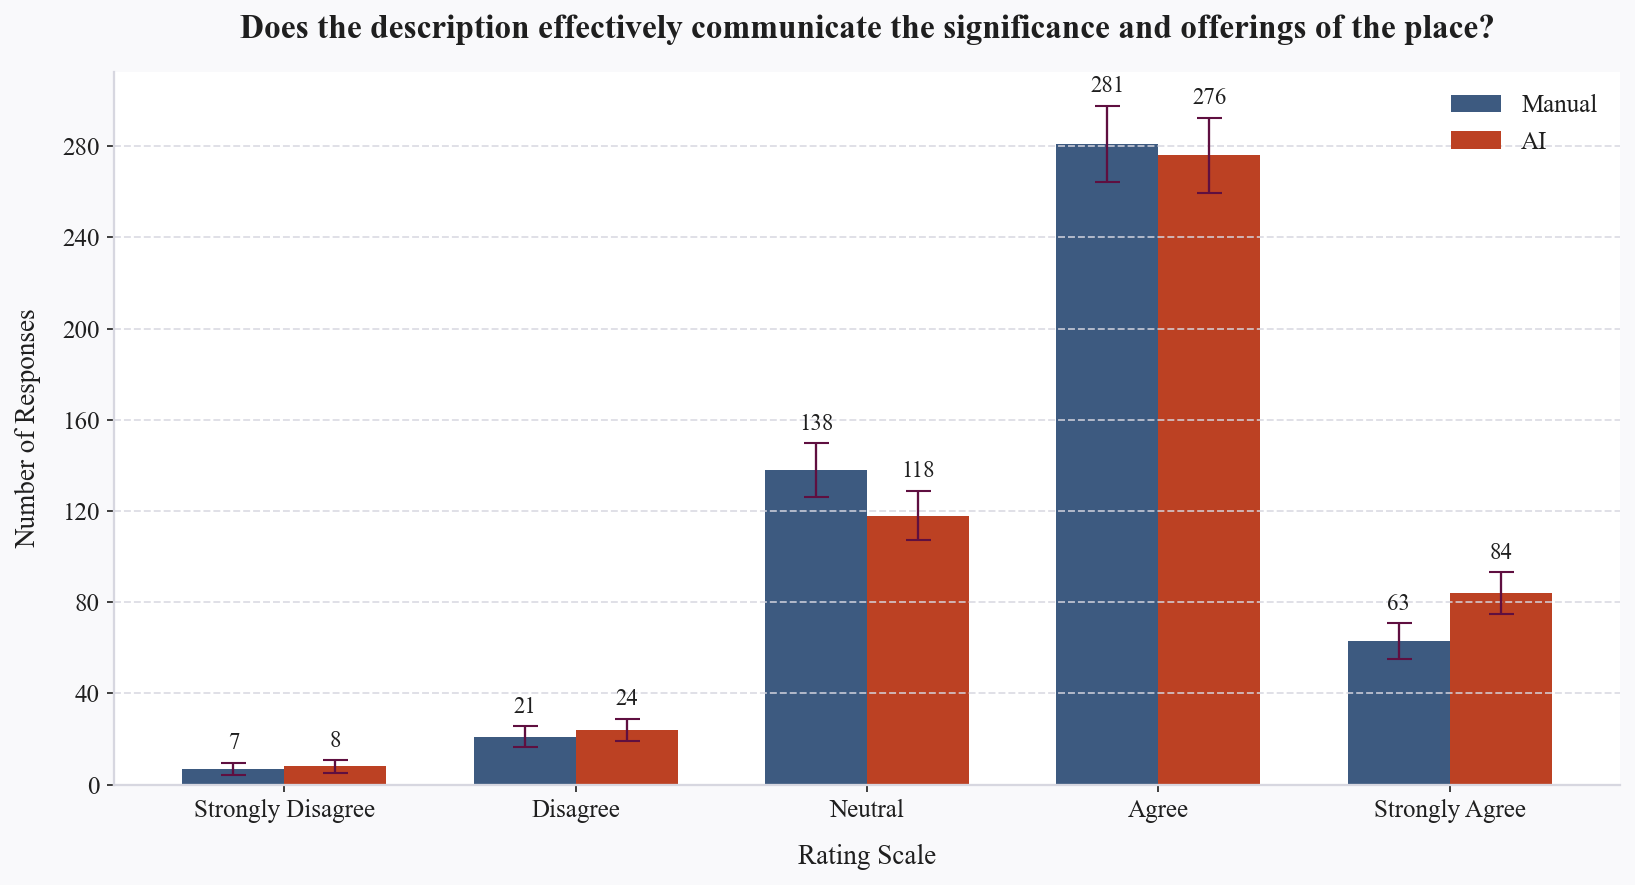

In [77]:
# Does the description effectively communicate the significance and offerings of the place?
cat_type = pd.CategoricalDtype(
        categories=['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'],
        ordered=True
    )
plot_graph(
    survey_df,
    cat_type,
    'manual_significance',
    'ai_significance',
    'Does the description effectively communicate the significance and offerings of the place?',
    slug="significance"
)

Saved figure to C:\Users\bksai\Documents\projects\github\PoI_survey\assets\figures\trust_comparison.png


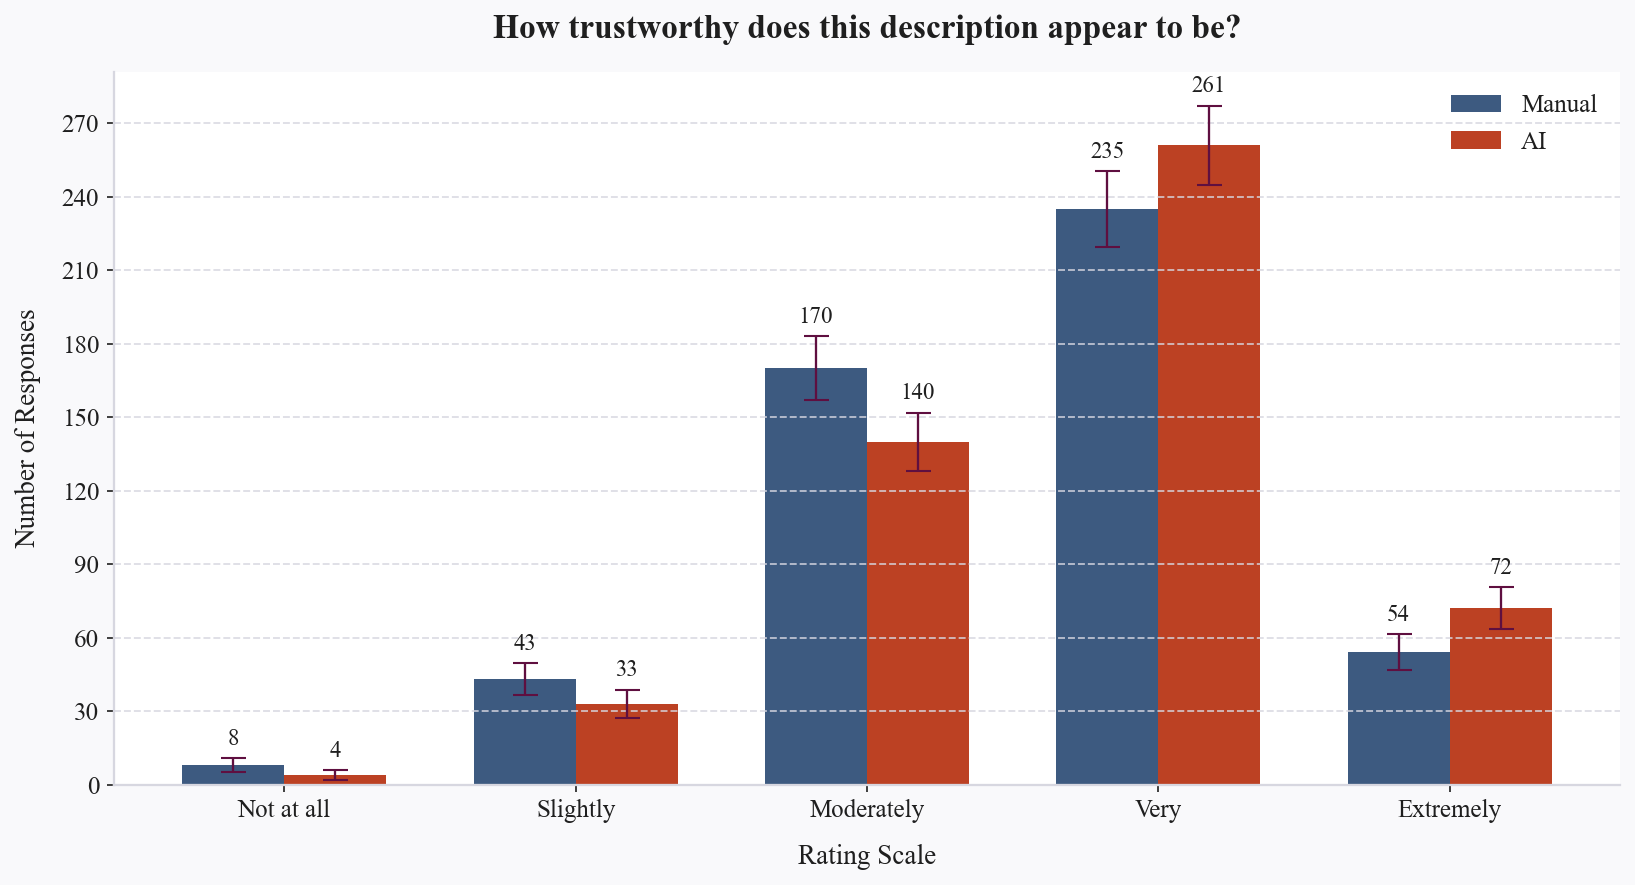

In [78]:
# How trustworthy does this description appear to be?
cat_type = pd.CategoricalDtype(
        categories=["Not at all", "Slightly", "Moderately", "Very", "Extremely"],
        ordered=True
    )
plot_graph(
    survey_df,
    cat_type,
    'manual_trust',
    'ai_trust',
    'How trustworthy does this description appear to be?',
    slug="trust"
)

Saved figure to C:\Users\bksai\Documents\projects\github\PoI_survey\assets\figures\clarity_comparison.png


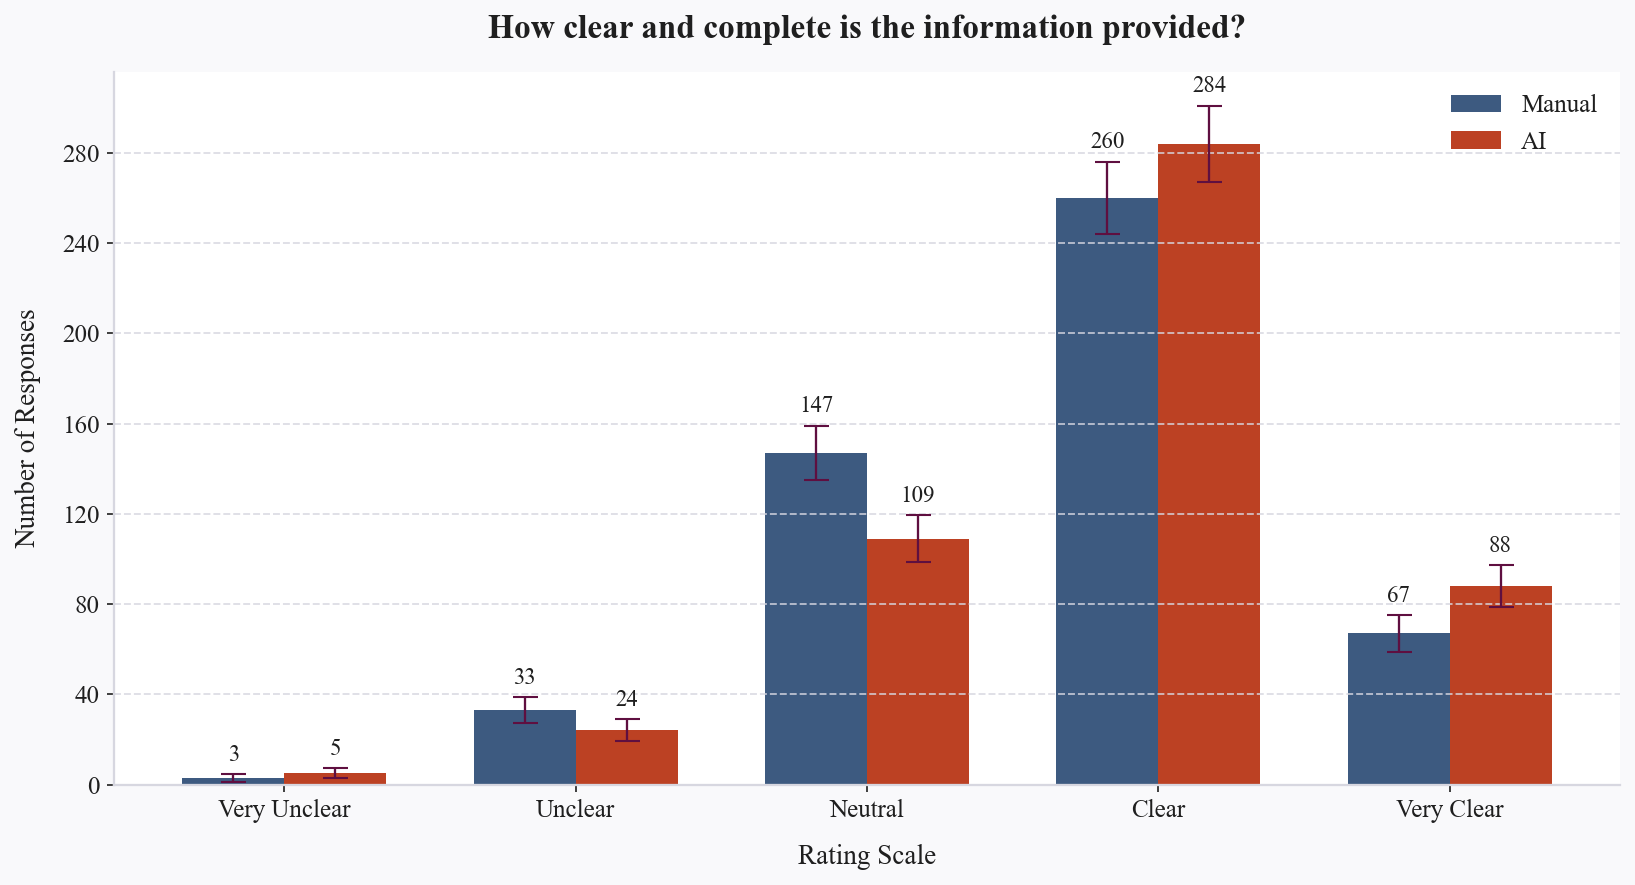

In [79]:
cat_type = pd.CategoricalDtype(
        categories=["Very Unclear", "Unclear", "Neutral", "Clear", "Very Clear"],
        ordered=True
    )
plot_graph(
    survey_df,
    cat_type,
    'manual_clarity',
    'ai_clarity',
    'How clear and complete is the information provided?',
    slug="clarity"
)

engaging_preference: engaging_preference
No Selection      0.0
Manual          220.0
AI Generated    221.0
Both equally     69.0
Name: count, dtype: float64
relevant_preference: relevant_preference
No Selection      0.0
Manual          272.0
AI Generated    150.0
Both equally     88.0
Name: count, dtype: float64
eager_preference: eager_preference
No Selection      0.0
Manual          223.0
AI Generated    210.0
Both equally     77.0
Name: count, dtype: float64
title_preference: title_preference
No Selection      0.0
Manual          247.0
AI Generated    171.0
Both equally     92.0
Name: count, dtype: float64
description_preference: description_preference
No Selection      0.0
Manual          245.0
AI Generated    181.0
Both equally     84.0
Name: count, dtype: float64


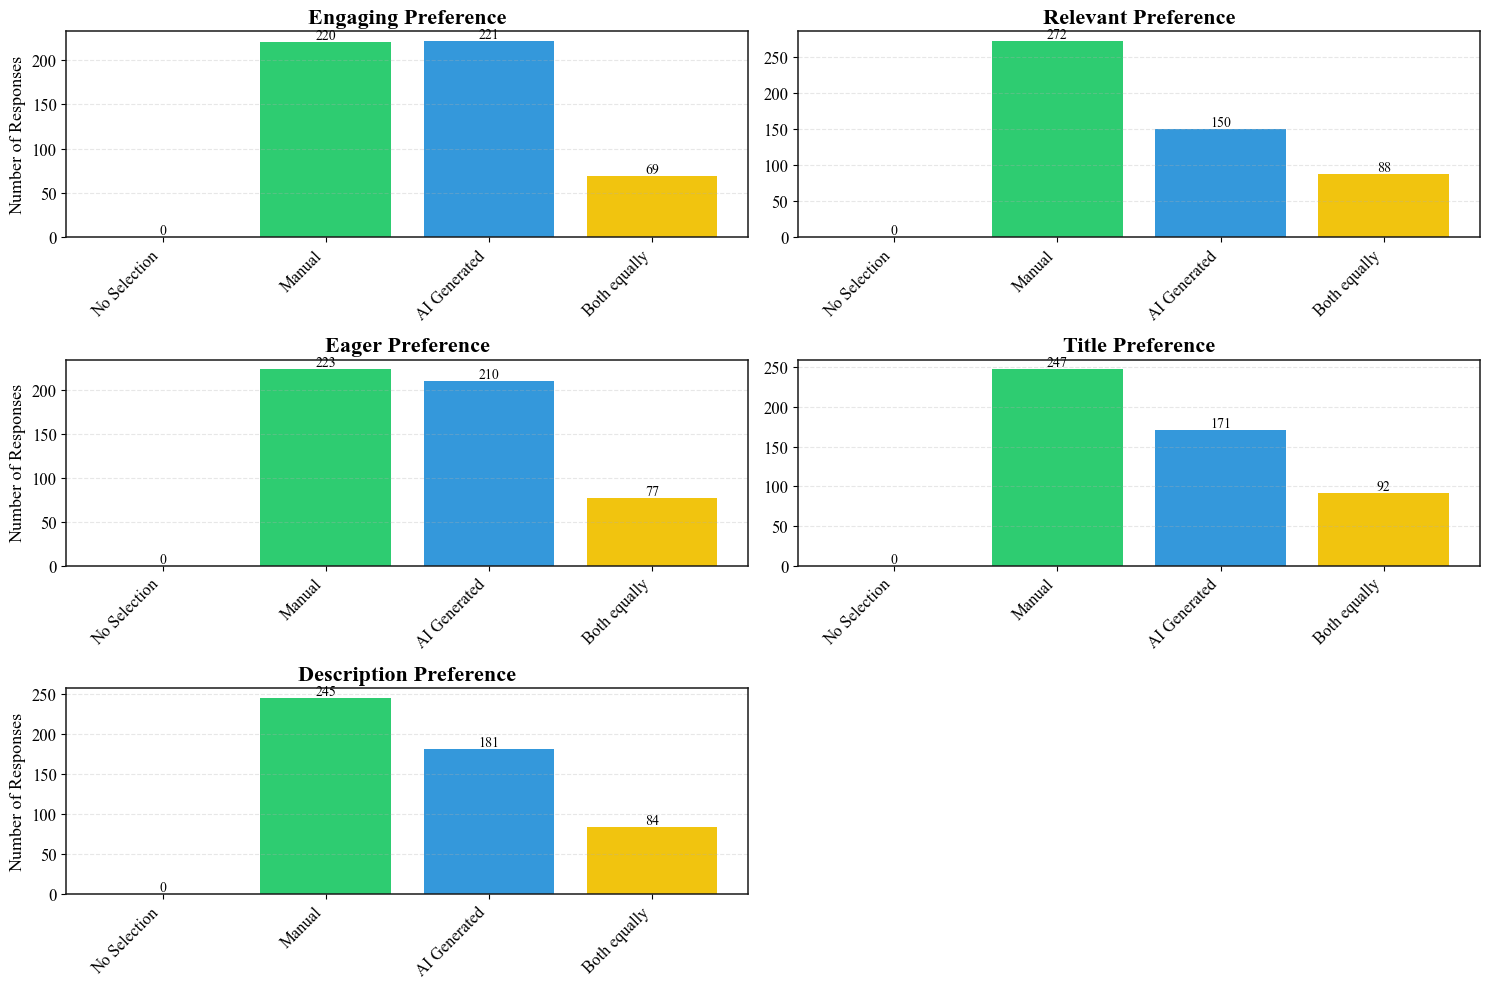

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data


# List of preference columns
preference_columns = [
    'engaging_preference', 
    'relevant_preference', 
    'eager_preference',
    'title_preference', 
    'description_preference'
]

# Function to replace versions based on is_manual_first
def replace_versions(row, column):
    value = row[column]
    if value in ['Version A', 'Version B']:
        if row['is_manual_first']:
            return 'Manual' if value == 'Version A' else 'AI Generated'
        else:
            return 'AI Generated' if value == 'Version A' else 'Manual'
    return value

# Apply the replacement for each preference column
for col in preference_columns:
    survey_df[col] = survey_df.apply(lambda row: replace_versions(row, col), axis=1)

# Create subplots for each preference
plt.figure(figsize=(15, 10))

# Define colors for each category
colors = {
    'No Selection': '#95a5a6',
    'Manual': '#2ecc71',
    'AI Generated': '#3498db',
    'Both equally': '#f1c40f'
}

# Define the order of categories
categories = ['No Selection', 'Manual', 'AI Generated', 'Both equally']

for i, column in enumerate(preference_columns, 1):
    plt.subplot(3, 2, i)
    
    # Count values and reindex to ensure all categories are present
    
    value_counts = survey_df[column].value_counts().reindex(categories).fillna(0)
    print(f"{column}: {value_counts}")
    
    # Create bar plot
    bars = plt.bar(value_counts.index, value_counts.values, 
                  color=[colors[cat] for cat in value_counts.index])
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')
    
    # Customize each subplot
    plt.title(column.replace('_', ' ').title())
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add y-label only for leftmost plots
    if i % 2 == 1:
        plt.ylabel('Number of Responses')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [81]:
survey_df['engaging_preference'].value_counts()

engaging_preference
AI Generated    221
Manual          220
Both equally     69
Name: count, dtype: int64

# loading final

In [100]:
final_response= pd.read_csv("./processed_data/processed_final_responses.csv")

In [83]:
final_response

,timestamp,overall_rating,comments,adaptation_rating,ai_comfort_rating,final_feedback,lottery_email,response_date,response_time
0,2025-01-26 04:50:32.387757,4.0,NaN,4.0,4.0,NaN,vikasalha@gmail.com,2025-01-26,04:50:32.387757
1,2025-01-27 18:27:01.006977,4.0,NaN,4.0,5.0,NaN,skycool2408@gmail.com,2025-01-27,18:27:01.006977
2,2025-01-25 12:32:34.044795,3.0,NaN,3.0,2.0,NaN,NaN,2025-01-25,12:32:34.044795
3,2024-12-18 08:54:40.324446,4.0,NaN,3.0,3.0,NaN,deepsynergy@gmail.com,2024-12-18,08:54:40.324446
4,2025-01-25 10:54:45.854198,NaN,NaN,NaN,NaN,NaN,unniashish13@gmail.com,2025-01-25,10:54:45.854198
5,2025-01-26 17:13:34.054604,4.0,NaN,5.0,5.0,NaN,NaN,2025-01-26,17:13:34.054604
6,2025-01-27 17:22:51.556760,4.0,NaN,4.0,4.0,NaN,gopalnayak.13@gmail.com,2025-01-27,17:22:51.556760
7,2025-01-25 17:10:49.560429,4.0,NaN,4.0,4.0,Satisfied,n.nitinsinha@gmail.com,2025-01-25,17:10:49.560429
8,2025-01-26 05:38:38.423458,NaN,NaN,NaN,NaN,It was a great experience to think through and...,swapnilsharma1@hotmail.com,2025-01-26,05:38:38.423458
9,2025-01-25 12:36:49.080825,4.0,NaN,5.0,4.0,AI generate descriptions are very engaging and...,ameer_khan.ali@outlook.com,2025-01-25,12:36:49.080825


In [101]:
#How would you rate your overall experience with the POI descriptions provided in this study?
print(f'How would you rate your overall experience with the POI descriptions provided in this study? \n \t {final_response['overall_rating'].mean(skipna=True)}')


How would you rate your overall experience with the POI descriptions provided in this study? 
 	 3.8823529411764706


In [102]:
#What is your opinion on the idea of automatically adapting POI descriptions based on user interests?
print(f'What is your opinion on the idea of automatically adapting POI descriptions based on user interests? \n \t {final_response['adaptation_rating'].mean(skipna=True)}')


What is your opinion on the idea of automatically adapting POI descriptions based on user interests? 
 	 3.75


In [103]:
#How comfortable are you with reading AI-generated descriptions when planning visits to new places?
print(f'How comfortable are you with reading AI-generated descriptions when planning visits to new places? \n \t {final_response['ai_comfort_rating'].mean(skipna=True)}')

How comfortable are you with reading AI-generated descriptions when planning visits to new places? 
 	 3.9411764705882355


In [89]:
!uv add scipy
import scipy.stats as stats
import numpy as np

# trust
# Contingency Table
data = np.array([
    [72, 54],
    [261, 235],
    [140, 170],
    [33, 43],
    [4, 8]
])

chi2, p, dof, expected = stats.chi2_contingency(data)

print(f"Chi-square statistic: {chi2:.2f}, p-value: {p:.4f}")

Resolved 59 packages in 739ms
 Downloaded scipy
Prepared 1 package in 2.93s
Installed 1 package in 172ms
 + scipy==1.17.0


Chi-square statistic: 9.49, p-value: 0.0500


In [ ]:
import scipy.stats as stats
import numpy as np

# significance
# Contingency Table
data = np.array([
    [84, 63],
    [276, 281],
    [118, 138],
    [24, 21],
    [8, 7]
])

chi2, p, dof, expected = stats.chi2_contingency(data)

print(f"Chi-square statistic: {chi2:.2f}, p-value: {p:.4f}")


Chi-square statistic: 4.87, p-value: 0.3005


In [ ]:
import scipy.stats as stats
import numpy as np

# Clarity
# Contingency Table
data = np.array([
    [88, 67],
    [284, 260],
    [109, 147],
    [24, 33],
    [5, 3]
])

chi2, p, dof, expected = stats.chi2_contingency(data)

print(f"Chi-square statistic: {chi2:.2f}, p-value: {p:.4f}")

Chi-square statistic: 11.47, p-value: 0.0218


In [99]:
metric_categories = {
    "significance": ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'],
    "trust": ["Not at all", "Slightly", "Moderately", "Very", "Extremely"],
    "clarity": ["Very Unclear", "Unclear", "Neutral", "Clear", "Very Clear"]
}

summary_tables = {}
for metric, categories in metric_categories.items():
    manual_col = f"manual_{metric}"
    ai_col = f"ai_{metric}"
    dtype = pd.CategoricalDtype(categories=categories, ordered=True)
    manual_counts = survey_df[manual_col].astype(dtype).value_counts().reindex(categories).fillna(0).astype(int)
    ai_counts = survey_df[ai_col].astype(dtype).value_counts().reindex(categories).fillna(0).astype(int)
    table = pd.DataFrame({"Manual": manual_counts, "AI": ai_counts})
    summary_tables[metric] = table
    print(f"\n=== {metric.upper()} ===")
    print(table)


=== SIGNIFICANCE ===
                   Manual   AI
Strongly Disagree       7    8
Disagree               21   24
Neutral               138  118
Agree                 281  276
Strongly Agree         63   84

=== TRUST ===
            Manual   AI
Not at all       8    4
Slightly        43   33
Moderately     170  140
Very           235  261
Extremely       54   72

=== CLARITY ===
              Manual   AI
Very Unclear       3    5
Unclear           33   24
Neutral          147  109
Clear            260  284
Very Clear        67   88


In [105]:
participant_count = len(survey_df_unique)
age_stats = survey_df_unique['age'].describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
travel_experience_counts = survey_df_unique['travel_experience'].value_counts().head(5)
travel_style_counts = survey_df_unique['preferred_travel_style'].value_counts().head(5)

print(f"Unique participants: {participant_count}")
print("\nAge stats:")
print(age_stats.round(2))
print("\nMost common travel experience levels:")
print(travel_experience_counts)
print("\nTop travel style preferences:")
print(travel_style_counts)

Unique participants: 51

Age stats:
count    51.00
mean     30.94
std       6.74
min      22.00
25%      24.50
50%      30.00
75%      37.00
max      49.00
Name: age, dtype: float64

Most common travel experience levels:
travel_experience
Intermediate    21
Experienced     19
Beginner         9
Expert           2
Name: count, dtype: int64

Top travel style preferences:
preferred_travel_style
['Luxury', 'Relaxation', 'Family-friendly']                                              3
['Budget', 'Family-friendly', 'Relaxation']                                              1
['Relaxation', 'Adventure', 'Group Tours', 'Road Trips', 'Family-friendly']              1
['Relaxation', 'Budget', 'Cultural', 'Solo']                                             1
['Road Trips', 'Family-friendly', 'Eco-tourism', 'Relaxation', 'Budget', 'Adventure']    1
Name: count, dtype: int64


In [106]:
print(f"Final-response sample size: {len(final_response)}")
print("\nFeedback scale summaries (1-5):")
print(final_response[['overall_rating','adaptation_rating','ai_comfort_rating']].describe().loc[['count','mean','std','min','25%','50%','75%','max']].round(2))

Final-response sample size: 28

Feedback scale summaries (1-5):
       overall_rating  adaptation_rating  ai_comfort_rating
count           17.00              16.00              17.00
mean             3.88               3.75               3.94
std              0.70               0.93               0.83
min              3.00               2.00               2.00
25%              3.00               3.00               4.00
50%              4.00               4.00               4.00
75%              4.00               4.25               4.00
max              5.00               5.00               5.00
